In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [11]:
FER_PATH = "Emotions_Dataset/fer2013.csv"

df = pd.read_csv(FER_PATH)

df.head()

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [12]:
print(df.shape)

df.info()

df.head()

df["emotion"].value_counts()

(35887, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  35887 non-null  int64 
 1   pixels   35887 non-null  object
 2   Usage    35887 non-null  object
dtypes: int64(1), object(2)
memory usage: 841.2+ KB


emotion
3    8989
6    6198
4    6077
2    5121
0    4953
5    4002
1     547
Name: count, dtype: int64

In [13]:
df.head()

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [14]:
df.columns

Index(['emotion', 'pixels', 'Usage'], dtype='object')

In [15]:
emotion_labels = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}

df["emotion_name"] = df["emotion"].map(emotion_labels)

df.head()

,emotion,pixels,Usage,emotion_name
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training,Angry
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training,Angry
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training,Fear
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training,Sad
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training,Neutral


In [16]:
df["emotion_name"].value_counts()

emotion_name
Happy       8989
Neutral     6198
Sad         6077
Fear        5121
Angry       4953
Surprise    4002
Disgust      547
Name: count, dtype: int64

In [17]:
# Step 2: Convert Pixel Strings to Images

def pixels_to_image(pixel_string):
    pixels = np.array(pixel_string.split(), dtype="float32")
    image = pixels.reshape(48, 48)
    return image

In [18]:
df["image"] = df["pixels"].apply(pixels_to_image)

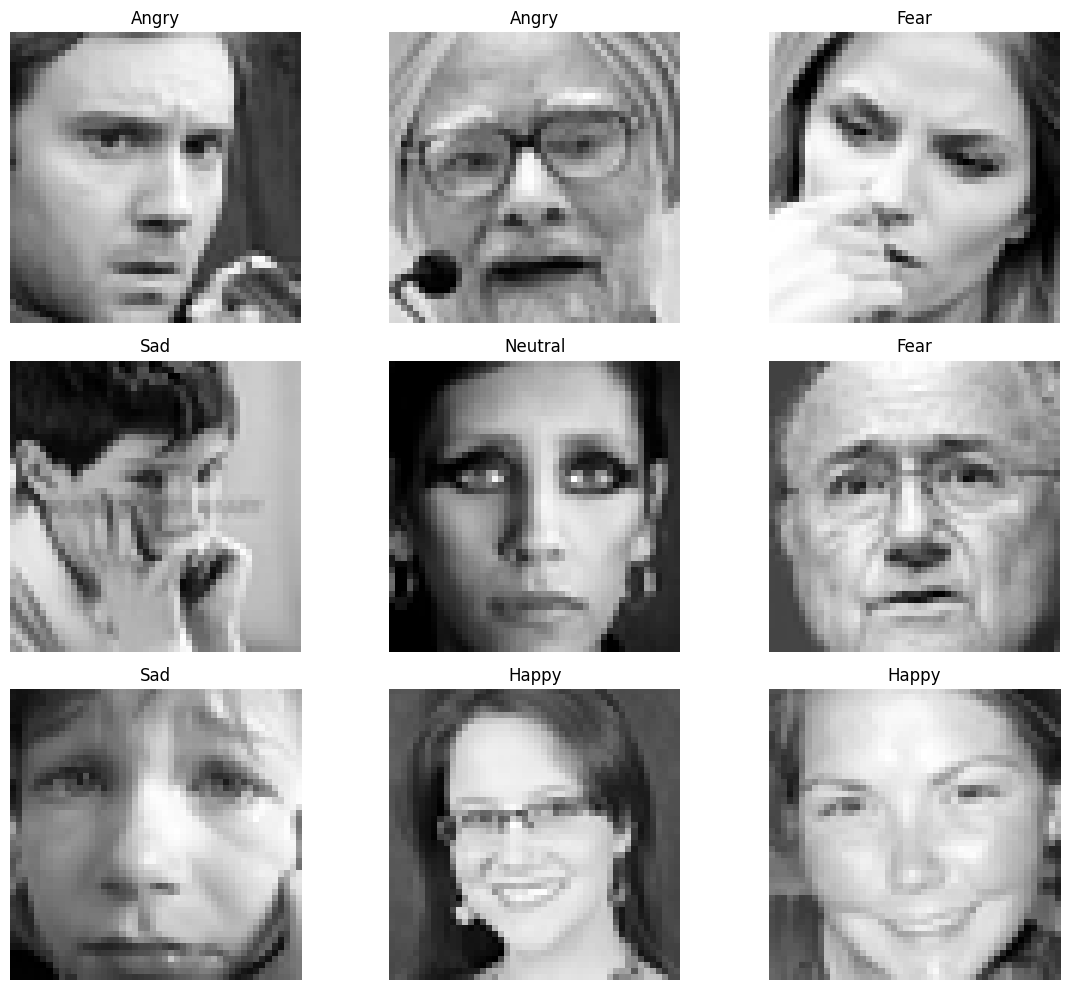

In [19]:
# Step 3: Display Sample Images

plt.figure(figsize=(12, 10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(df.iloc[i]["image"], cmap="gray")

    plt.title(df.iloc[i]["emotion_name"])

    plt.axis("off")

plt.tight_layout()

plt.show()


In [20]:
# Split dataset using the official FER2013 split

train_df = df[df["Usage"] == "Training"].copy()
val_df = df[df["Usage"] != "Training"].copy()

print("Training Images :", len(train_df))
print("Validation Images :", len(val_df))

Training Images : 28709
Validation Images : 7178


In [21]:
# Create training and validation arrays

X_train = np.stack(train_df["image"].values)
X_val = np.stack(val_df["image"].values)

y_train = train_df["emotion"].values
y_val = val_df["emotion"].values

print("X_train Shape :", X_train.shape)
print("X_val Shape   :", X_val.shape)
print("y_train Shape :", y_train.shape)
print("y_val Shape   :", y_val.shape)

X_train Shape : (28709, 48, 48)
X_val Shape   : (7178, 48, 48)
y_train Shape : (28709,)
y_val Shape   : (7178,)


In [22]:
# Normalize pixel values between 0 and 1

X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0

print("Normalization Complete!")

Normalization Complete!


In [23]:
# Step 4: One-Hot Encode the Labels
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=7)
y_val = to_categorical(y_val, num_classes=7)

print("y_train Shape :", y_train.shape)
print("y_val Shape   :", y_val.shape)

y_train Shape : (28709, 7)
y_val Shape   : (7178, 7)


In [24]:
# Step 5 - Data Augumentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator()

In [25]:
print(X_train.shape)
print(X_val.shape)

(28709, 48, 48)
(7178, 48, 48)


In [26]:
# Add the missing value
X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)

In [27]:
print(X_train.shape)
print(X_val.shape)

(28709, 48, 48, 1)
(7178, 48, 48, 1)


In [43]:
# Create the Generators Again
train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=16,
    shuffle=True
)

val_generator = val_datagen.flow(
    X_val,
    y_val,
    batch_size=16,
    shuffle=False
)

print("Generators Created Successfully!")

Generators Created Successfully!


In [44]:
# Import the required labels

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

In [45]:
# Build the CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

model = Sequential([

    # Block 1
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(48,48,1)),
    BatchNormalization(),

    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),

    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),

    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),

    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),

    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')

])


In [46]:
# Compile the Model

model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

In [47]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)                   │ (None, 48, 48, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_24               │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_25 (Conv2D)                   │ (None, 48, 48, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_25               │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_26 (Conv2D)                   │ (None, 24, 24, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_26               │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_27 (Conv2D)                   │ (None, 24, 24, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_27               │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_28 (Conv2D)                   │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_28               │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_29 (Conv2D)                   │ (None, 12, 12, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_29               │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,469,927 (5.61 MB)

 Trainable params: 1,469,031 (5.60 MB)

 Non-trainable params: 896 (3.50 KB)

In [48]:
# Callbacks - Earlystoppings

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

In [50]:
import os

os.makedirs("models", exist_ok=True)

checkpoint = ModelCheckpoint(
    "models/emotion_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [52]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/15
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.2764 - loss: 1.7567
Epoch 1: val_accuracy did not improve from 0.29284
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 389s 217ms/step - accuracy: 0.2787 - loss: 1.7435 - val_accuracy: 0.2636 - val_loss: 1.7273
Epoch 2/15
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.2820 - loss: 1.7136
Epoch 2: val_accuracy improved from 0.29284 to 0.33394, saving model to models/emotion_model.keras

Epoch 2: finished saving model to models/emotion_model.keras
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 414s 231ms/step - accuracy: 0.2837 - loss: 1.7083 - val_accuracy: 0.3339 - val_loss: 1.5518
Epoch 3/15
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.2900 - loss: 1.6840
Epoch 3: val_accuracy improved from 0.33394 to 0.39426, saving model to models/emotion_model.keras

Epoch 3: finished saving model to models/emotion_model.keras
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 399s 222ms/step - accuracy: 0.3068 - loss: 1.6625 - val_accuracy: 0.3943 - val_l

In [54]:
model.save("models/emotion_model.keras")

print("Emotion Model Saved Successfully!")

Emotion Model Saved Successfully!


In [55]:
loss, accuracy = model.evaluate(val_generator)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

449/449 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - accuracy: 0.5769 - loss: 1.1013
Validation Loss : 1.1013263463974
Validation Accuracy : 0.5769016146659851


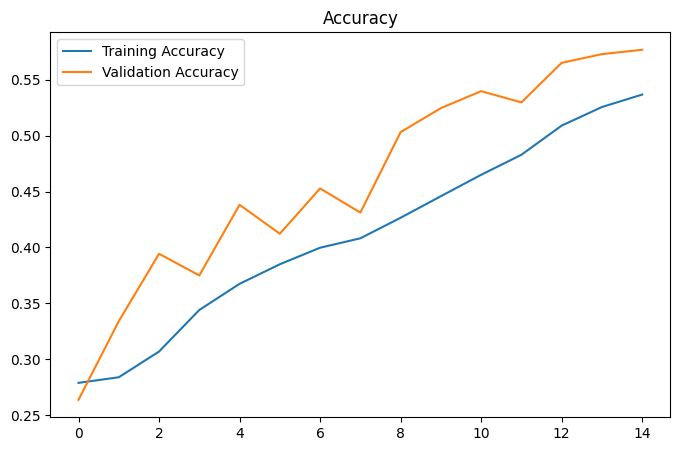

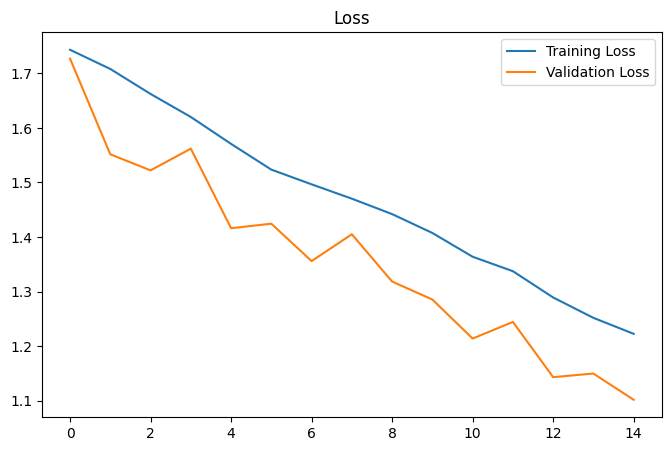

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()

NameError: name 'model' is not defined